# Experiment 1 — champion-level statistical analysis (LGD)

The full **all-learner** pairwise analysis lives in `Experiment1.2-PD-Stat` / `Experiment1.5-LGD-Stat`. Here we zoom in on **one champion per model family** to answer the paper's actual question — *is the tabular foundation model competitive with the established approaches?* — with far more statistical power and a cleaner interpretation.

**Champions (fixed a priori, one per family):**
- **TabPFN-3** — strongest tabular foundation model.
- **CatBoost** — strongest gradient-boosting model.
- **TabM** — strongest deep-tabular model for regression.
- **Linear Regression** — the regulatory / industry-standard credit baseline.

They are chosen by their **established standing, not by their score on these datasets**, and the complete all-learner analysis stays in the `-Stat` notebook — so this focused view is a *confirmatory companion*, not cherry-picking.

**Methodology.** Every test uses **N = number of datasets** (one five-fold-averaged score per dataset; folds feed only PAMA / variance, never as independent observations). The control-method analysis (§4) uses **TabPFN-3 as the control**.

> **Small-sample caveat.** With only 7 LGD datasets the frequentist tests are low-powered — read them together with the **Bayesian** analysis (§7), which is built for small N.

In [1]:
import sys
import pandas as _pd
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.visualizations.experiment_plots import apply_style, reset_figure_dir, load_summary, champion_methods
from src.methods.method_config import FOUNDATION_METHODS
from src.methods.method_names import display_name
from src.utils import statistical_testing as st
from src.utils.report import (notebook_report, capture, section,
                             preview, omnibus_frame)
apply_style()

RESULTS_ROOT = results_root()
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment1' / 'lgd_family')
FND = sorted(FOUNDATION_METHODS)

METRIC    = 'R2'
CONTROL   = 'tabpfn_v3'
CHAMPIONS = champion_methods('lgd')  # inclusion list from notebooks/CONFIG_NOTEBOOKS.yaml


In [2]:
df       = load_summary(SUMMARY_DIR, experiment='experiment1', task='lgd', hpo_mode='HPO')
df_folds = load_summary(SUMMARY_DIR, experiment='experiment1', task='lgd', aggregated=False, hpo_mode='HPO')

# Restrict to the family champions. Data stays on the raw registry keys;
# only the figure labels are mapped to the standard display names.
present = set(df['method'].unique())
champs  = [m for m in CHAMPIONS if m in present]
missing = [m for m in CHAMPIONS if m not in present]
if missing:
    pass
df_c    = df[df['method'].isin(champs)]
folds_c = df_folds[df_folds['method'].isin(champs)]
mat     = st.metric_matrix(df_c, METRIC)
mat     = mat[[m for m in champs if m in mat.columns]]   # enforce champion order
ranks   = st.average_ranks(mat)                          # best-first, reused below


[CONFIG_NOTEBOOKS.yaml] excluded from this analysis: tabfm
[CONFIG_NOTEBOOKS.yaml] excluded from this analysis: tabfm


## 1. PAMA — how often is each champion the single best?

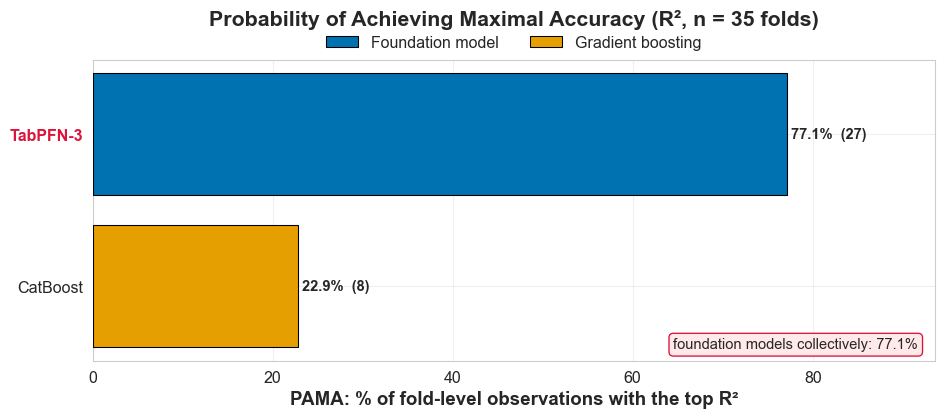

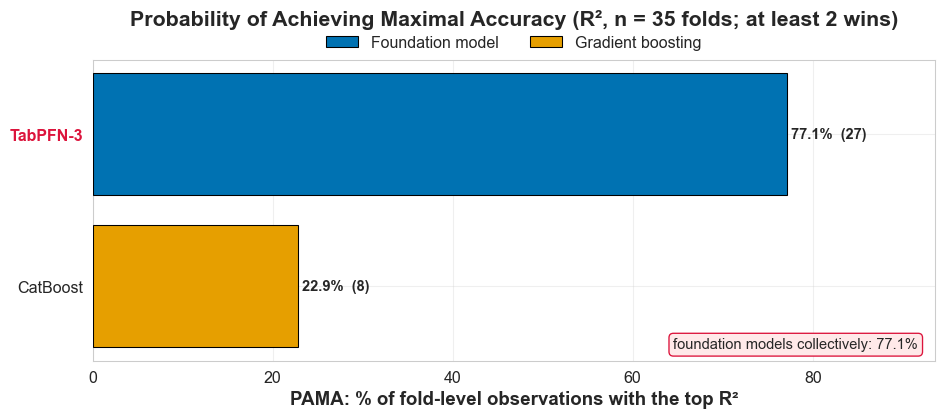

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd_family/lgd_pama_min2wins.pdf')

In [3]:
st.plot_pama_bars(folds_c, METRIC, metric_name=METRIC, foundation_methods=FND,
                  out_path=FIGURES_DIR / 'lgd_pama.pdf')
# Same PAMA, restricted to champions that win on >= 2 (dataset, fold) observations.
st.plot_pama_bars(folds_c, METRIC, metric_name=METRIC, foundation_methods=FND,
                  min_wins=2, out_path=FIGURES_DIR / 'lgd_pama_min2wins.pdf')


## 2. Do the champions differ at all? — omnibus tests

Friedman + Iman–Davenport, plus the more powerful Friedman-Aligned-Ranks and Quade alternatives. All use N = datasets.

In [4]:
f = st.friedman_test(mat)
fa = st.friedman_aligned_ranks_test(mat); qu = st.quade_test(mat)
preview(omnibus_frame(Friedman=f, **{'Aligned ranks': fa, 'Quade': qu}),
        label='Omnibus tests')


**Omnibus tests**

,N,k,chi2_F,p_chi2,iman_davenport_F,p_iman_davenport,aligned_ranks_chi2,p,quade_F
Friedman,7.0,4.0,18.771429,0.000305,50.538462,0.0,NaN,NaN,NaN
Aligned ranks,7.0,4.0,NaN,NaN,NaN,NaN,15.315266,0.001566,NaN
Quade,7.0,4.0,NaN,NaN,NaN,NaN,NaN,0.000080,13.316689


## 3. The ranking, visually — critical-difference diagram

With only a handful of champions the Nemenyi CD is narrow, so the diagram can actually separate them. Champions joined by a bar are statistically indistinguishable.

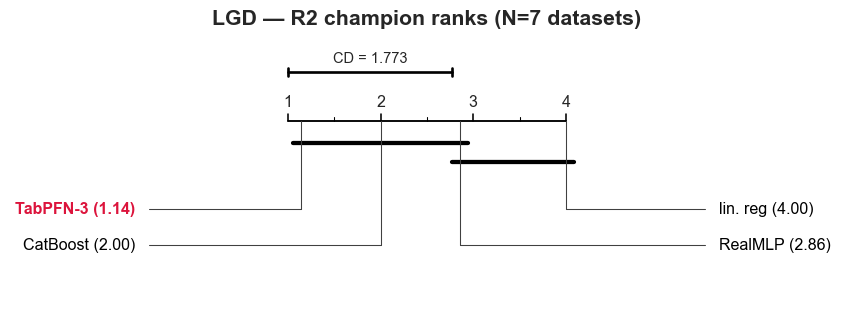

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd_family/lgd_cd_r2.pdf')

In [5]:
st.plot_cd_diagram(ranks, st.nemenyi_cd(mat.shape[1], mat.shape[0]),
                   title=f'LGD — {METRIC} champion ranks (N={mat.shape[0]} datasets)',
                   out_path=FIGURES_DIR / 'lgd_cd_r2.pdf')


## 4. Is the foundation model the best? — TabPFN-3 as control

A **control-method** design (Demšar §3.2.3): instead of all pairs, every champion is compared **only against TabPFN-3**. This is the most powerful, most on-topic test — it directly answers *is the TFM significantly better than each established approach?* The Bonferroni–Dunn critical difference is the rank gap a champion must exceed to differ from the control; the table gives the adjusted p-values (several step procedures).

In [6]:
cd_bd = st.bonferroni_dunn_cd(mat.shape[1], mat.shape[0])
ctrl = st.control_apv_table(mat, control=CONTROL)
preview(ctrl.round(4),
        label=f'Adjusted p-values vs {display_name(CONTROL)} (Bonferroni-Dunn CD = {cd_bd:.3f})')


**Adjusted p-values vs TabPFN-3 (Bonferroni-Dunn CD = 1.652)**

,control,method,z,p_unadjusted,bonferroni_dunn,holm,hochberg,hommel,holland,finner,li
0,tabpfn_v3,LinearRegression,4.1404,0.0000,0.0001,0.0001,0.0001,0.0001,0.0001,0.0001,0.0000
1,tabpfn_v3,realmlp,2.4842,0.0130,0.0389,0.0260,0.0260,0.0260,0.0258,0.0194,0.0163
2,tabpfn_v3,catboost,1.2421,0.2142,0.6426,0.2142,0.2142,0.2142,0.2142,0.2142,0.2142


## 5. Every head-to-head — Win/Loss matrix

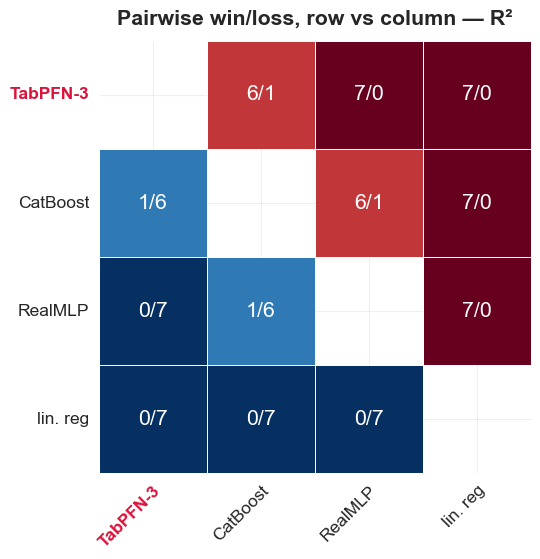

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd_family/lgd_winloss.pdf')

In [7]:
st.plot_wilcoxon_wl_matrix_compact(mat, metric_name=METRIC,
                                   out_path=FIGURES_DIR / 'lgd_winloss.pdf')


## 6. Which differences are significant? — Wilcoxon & t-test (Holm) + adjusted-p matrix

Significant pairwise differences in R² (Wilcoxon signed-rank, Holm-corrected, alpha = 0.05):
  0 of 6 pairs significant.

  (none reach significance after Holm correction)
Significant pairwise differences in R² (paired t-test, Holm-corrected, alpha = 0.05):
  0 of 6 pairs significant.

  (none reach significance after Holm correction)


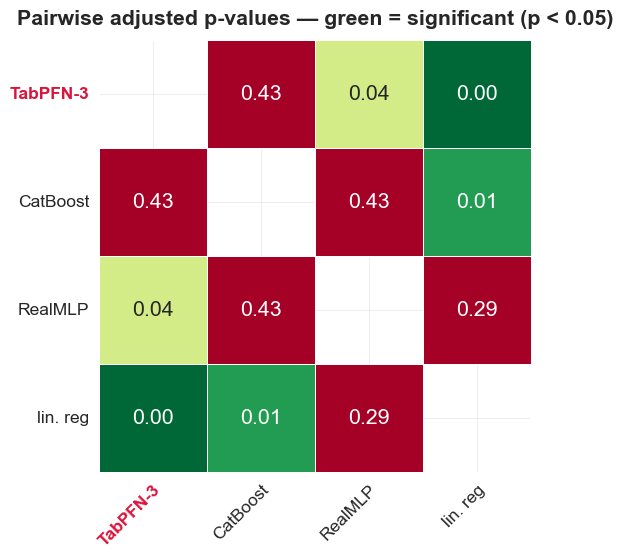

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment1/lgd_family/lgd_significance.pdf')

In [8]:
st.significant_pairs_text(mat, test='wilcoxon', metric_name=METRIC)
st.significant_pairs_text(mat, test='ttest', metric_name=METRIC)
apv = st.pairwise_apv_table(mat)
st.plot_significance_matrix_compact(apv, mat.columns, order=list(ranks.index),
                                    out_path=FIGURES_DIR / 'lgd_significance.pdf')


## 7. The practical question — Bayesian signed-rank with a ROPE

For each champion, the probability that **TabPFN-3** is better / practically equivalent (ROPE = ±0.01) / worse (Benavoli et al., 2017). No significance threshold — ideal for this small number of datasets.

In [9]:
_rows = {}
for m in [x for x in champs if x != CONTROL]:
    _rows[f'{display_name(CONTROL)} vs {display_name(m)}'] = st.bayesian_signed_rank_test(
        mat[CONTROL], mat[m], rope=0.01)
preview(_pd.DataFrame(_rows).T.round(4),
        label='Bayesian signed-rank test vs the control (ROPE = 0.01)')


**Bayesian signed-rank test vs the control (ROPE = 0.01)**

,rope,P_left,P_rope,P_right,P_left_is_max,P_rope_is_max,P_right_is_max
TabPFN-3 vs CatBoost,0.01,0.0473,0.2002,0.7525,0.005,0.0363,0.9587
TabPFN-3 vs RealMLP,0.01,0.0000,0.0275,0.9725,0.000,0.0003,0.9997
TabPFN-3 vs lin. reg,0.01,0.0000,0.0275,0.9725,0.000,0.0003,0.9997


> **The story in one line.** PAMA shows who wins most often; the omnibus tests confirm the champions genuinely differ; the CD diagram and Win/Loss matrix show *who* and *by how much*; the **control-method** test answers whether TabPFN-3 beats each established approach; and the **Bayesian ROPE** analysis turns that into a practical probability of superiority — across only the methods a practitioner would actually consider.

## Summary — the notebook's single printed report

Everything above, in text: this is the notebook's ONLY printed output, so `results/All_Results.md` is a complete text record of the analysis.

In [10]:
notebook_report(
    'Experiment 1 - LGD champion statistics',
    notebook='Experiment1.6-LGD-FamilyStat.ipynb',
    about=('Champion-level statistics on LGD R2: one representative per model family with TabPFN-3 as the control. With only 7 datasets the Bayesian ROPE result is the more informative one.'),
    sections=[
        section('Champions compared',
                ', '.join(display_name(m) for m in CHAMPIONS) + f'  (control: {display_name(CONTROL)})'),
        section('Matrix shape', f'{mat.shape[1]} champions x {mat.shape[0]} datasets on R2'),
        section('PAMA - fold-level win share per champion',
                st.pama_fold_level(folds_c, 'R2')),
        section('Full statistical battery (champion level, control = TabPFN-3)',
                capture(st.statistical_report, df_c, folds_c, metric='R2',
                        task_name='LGD champions', higher_is_better=True,
                        focus=champs, control=CONTROL)),
    ],
)

EXPERIMENT 1 - LGD CHAMPION STATISTICS -- COMPLETE TEXT SUMMARY
Source notebook : notebooks/Experiment1.6-LGD-FamilyStat.ipynb
Contents        : Champion-level statistics on LGD R2: one representative per model family with TabPFN-3 as the control. With only 7 datasets the Bayesian ROPE result is the more informative one.
Sections        : 4

This is the notebook's ONLY printed output: every table and figure-backing
number it produces is reproduced below, so results/All_Results.md is a
complete text record of the analysis.

------------------------------------------------------------------------------
[1] Champions compared
------------------------------------------------------------------------------
TabPFN-3, CatBoost, RealMLP, lin. reg  (control: TabPFN-3)

------------------------------------------------------------------------------
[2] Matrix shape
------------------------------------------------------------------------------
4 champions x 7 datasets on R2

-----------------------

"==============================================================================\nEXPERIMENT 1 - LGD CHAMPION STATISTICS -- COMPLETE TEXT SUMMARY\n==============================================================================\nSource notebook : notebooks/Experiment1.6-LGD-FamilyStat.ipynb\nContents        : Champion-level statistics on LGD R2: one representative per model family with TabPFN-3 as the control. With only 7 datasets the Bayesian ROPE result is the more informative one.\nSections        : 4\n\nThis is the notebook's ONLY printed output: every table and figure-backing\nnumber it produces is reproduced below, so results/All_Results.md is a\ncomplete text record of the analysis.\n\n------------------------------------------------------------------------------\n[1] Champions compared\n------------------------------------------------------------------------------\nTabPFN-3, CatBoost, RealMLP, lin. reg  (control: TabPFN-3)\n\n-------------------------------------------------------